In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("aba_phenotype_data_df.csv")

# Preview data
df.head()

,rownames,structure_acronym.x,ihc_iba1_ffpe,ihc_gfap_ffpe,id
0,98,TCx,0.037062,0.021808,X488395315
1,11,FWM,0.044044,NaN,X496100277
2,1,FWM,0.046522,0.066385,X496100278
3,4,TCx,0.073980,0.018081,X496100279
4,6,HIP,0.112440,0.075589,X496100281


In [8]:
print(df.shape)
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

(377, 5)
<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rownames             377 non-null    int64  
 1   structure_acronym.x  377 non-null    str    
 2   ihc_iba1_ffpe        363 non-null    float64
 3   ihc_gfap_ffpe        345 non-null    float64
 4   id                   377 non-null    str    
dtypes: float64(2), int64(1), str(2)
memory usage: 19.6 KB
None
         rownames  ihc_iba1_ffpe  ihc_gfap_ffpe
count  377.000000     363.000000     345.000000
mean   189.000000       0.058751       0.043076
std    108.974768       0.023304       0.020907
min      1.000000       0.009662       0.008379
25%     95.000000       0.044452       0.026978
50%    189.000000       0.056155       0.039175
75%    283.000000       0.072313       0.053694
max    377.000000       0.152303       0.121641
rownames                0
structure_acronym.x     0


In [5]:
print(df.columns)

Index(['rownames', 'structure_acronym.x', 'ihc_iba1_ffpe', 'ihc_gfap_ffpe',
       'id'],
      dtype='str')


In [7]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_preds))
print(classification_report(y_test, et_preds))

Extra Trees Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
print(df.columns)

Index(['rownames', 'structure_acronym.x', 'ihc_iba1_ffpe', 'ihc_gfap_ffpe',
       'id'],
      dtype='str')


In [16]:
print(df.head())
print(df.columns)

   rownames structure_acronym.x  ihc_iba1_ffpe  ihc_gfap_ffpe          id
0        98                 TCx       0.037062       0.021808  X488395315
1        11                 FWM       0.044044            NaN  X496100277
2         1                 FWM       0.046522       0.066385  X496100278
3         4                 TCx       0.073980       0.018081  X496100279
4         6                 HIP       0.112440       0.075589  X496100281
Index(['rownames', 'structure_acronym.x', 'ihc_iba1_ffpe', 'ihc_gfap_ffpe',
       'id'],
      dtype='str')


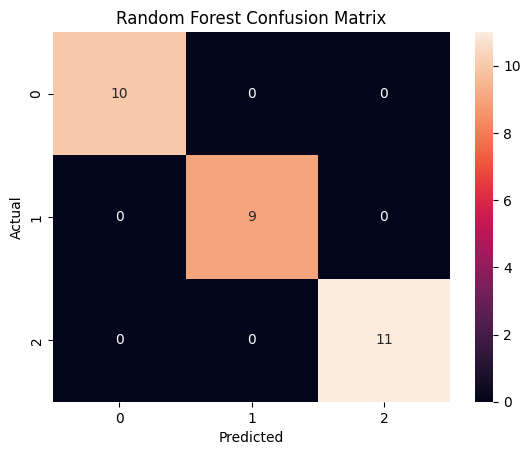

In [17]:
cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()